# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/innouguru/flyrank-intenship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

**Which content pages should be prioritized for review based on their search and engagement signals?**

### Decision

Given limited editorial capacity, which pages should the content team review first?

This work supports a ranking-based decision rather than an automated editorial decision. The model produces a score that is used to rank content pages so that editors can review higher-priority candidates first. The ranking is a recommendation and not a final verdict on whether a page should be refreshed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This work uses the FlyRank Warehouse Dataset, specifically the
`fact_content_daily_performance` table. The source table contains daily
performance records for individual content items and clients.

The modeling data covers October 1, 2025 through February 28, 2026.
Records were included only when both `gsc_data_available` and
`ga4_data_available` were true.

Daily records were aggregated to monthly client-content observations.
The resulting features were monthly GSC impressions, monthly GSC clicks,
impression-weighted average GSC position, monthly GA4 pageviews, and
monthly GA4 engaged sessions.

Rows with `gsc_avg_position = 0` were excluded from the position-based
analysis because zero is not a valid search-ranking position.

The modeling population was further restricted to pages identified by
the Week 4 position-aware CTR rule as potential review candidates.
Future-month outcome fields were used to construct the evaluation target
but were not used as model features.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Candidate definition

The rule-based baseline identified potential review candidates using a
position-aware CTR rule. Content pages were grouped into position-peer
buckets, and the median CTR was calculated for each bucket. A page became
a candidate when its CTR was at least 30% below the median CTR of the
position-peer group it belonged to.

The resulting candidate pool was used as the population for the machine
learning ranking task.

### Target definition

The target represents a future-month outcome rather than the page's
current performance.

For each current-month candidate, the following month's CTR was compared
with the following month's position-peer median CTR. A positive outcome
was assigned when:

`next_month_ctr >= next_month_peer_median_ctr`

This produces a binary target representing future peer-relative CTR
recovery.

Future-month values used to construct this target were not provided to
the model as input features.

### Features

The Random Forest model used five current-month search and engagement
signals:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `ga4_pageviews`
- `ga4_engaged_sessions`

The features were selected because they describe observable search
performance and engagement available at the time the recommendation would
be generated.

The CTR-derived candidate rule and future outcome fields were excluded
from the model features. In particular, the future-month variables were
excluded because they were used to construct the target. Including them
would allow the model to learn information about the outcome it was
supposed to predict.

### Model

A Random Forest classifier was used to learn the relationship between the
five current-month signals and the future peer-relative CTR recovery
target.

The model produces a probability score for each candidate. Candidates
are ranked from highest to lowest score, creating a prioritized review
list.

### Validation design

The evaluation follows a time-aware design to avoid using future
information to evaluate an earlier recommendation.

- **October–December 2025:** model training
- **January 2026:** model selection
- **February 2026:** final holdout evaluation

The February holdout was not used to select the model. It was reserved
for the final comparison between the Random Forest ranking and the
Week-4 rule-based baseline.

### Evaluation metric

The primary evaluation metric is Precision@50: the proportion of the
50 highest-ranked candidates whose target indicates future peer-relative
CTR recovery.

This metric matches the operational decision because editors have
limited capacity and need a prioritized list of candidates to review.

### Leakage checks

The feature set was audited to ensure that variables used to construct
the target were not included as model inputs. The temporal split also
prevents later observations from being used to train or select a model
that is evaluated on an earlier period.

The final evaluation therefore measures the ranking on a held-out month
that was not used for model selection.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Random Forest ranking was evaluated against the Week-4 rule-based
baseline on the same February 2026 holdout data using Precision@50.

| Method | Evaluation period | Precision@50 |
|---|---|---:|
| Week-4 rule-based baseline | February 2026 | 0.34 |
| Random Forest | February 2026 | 0.80 |

The Random Forest achieved a higher Precision@50 than the rule-based
baseline on the February holdout, identifying a larger proportion of
future peer-relative CTR recovery outcomes within its top 50 ranked
candidates.

The measured difference was 0.46 Precision@50 points. This result is
evidence that the Random Forest produced a more effective ranking than
the baseline under this evaluation setup.

The result should be interpreted as a ranking improvement on the
holdout data, not as evidence that the model causes CTR improvement or
that every highly ranked page requires a content refresh.

## 5. Limitations

*What this work cannot claim.*

- This work is a decision-support ranking system, not an automated content
refresh system. The model identifies and ranks candidates for human
review; it does not determine that a page must be refreshed.

- The target is a proxy for future peer-relative CTR recovery. It does not
directly measure whether a content refresh was successful, because the
analysis does not observe a controlled before-and-after editorial
intervention.

- The evaluation is based on historical observational data. The higher
Precision@50 measured for the Random Forest therefore does not establish
that using the model will cause CTR or other engagement metrics to
improve.

- The model uses five search and engagement signals. Other factors that
may influence editorial decisions, such as search intent, content
quality, business importance, SERP context, and recent editorial
changes, are not represented in the model.

- The February 2026 holdout provides an honest evaluation period for this
work, but it is still a single historical holdout period. Performance
may differ on other months, clients, content types, or future data.

- The action queue is therefore intended as a prioritized review
queue. Editors should apply contextual judgment to each recommendation
and may reject or override a recommendation when the page context does
not support an intervention.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final output is a ranked review queue containing the 50 highest-scoring
candidate pages. Candidates are ordered by the Random Forest model score,
with higher scores receiving higher priority for review.

Each candidate retains the reason code
`CTR_BELOW_POSITION_PEERS`, which identifies why the page entered the
candidate pool.

The initial action is determined by search exposure:

| Condition | Initial recommendation | Rationale |
|---|---|---|
| `gsc_impressions <= 100` | **MONITOR** | Limited search exposure; gather more evidence before intervention. |
| `gsc_impressions > 100` | **SERP_REVIEW** | Sufficient search exposure for human review of search intent and SERP presentation. |

The action queue is intended to help editors allocate limited review
capacity. A recommendation is not a verdict. Editors should review the
page's actual context and may accept, modify, or reject the suggested
action based on factors not represented in the model.

The model does not determine that a page should be refreshed, and it does
not perform the editorial action itself. The final decision remains with
the content team.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Model vs baseline

The primary result is the Precision@50 comparison between the Week-4
rule-based baseline and the Random Forest on the February 2026 holdout.

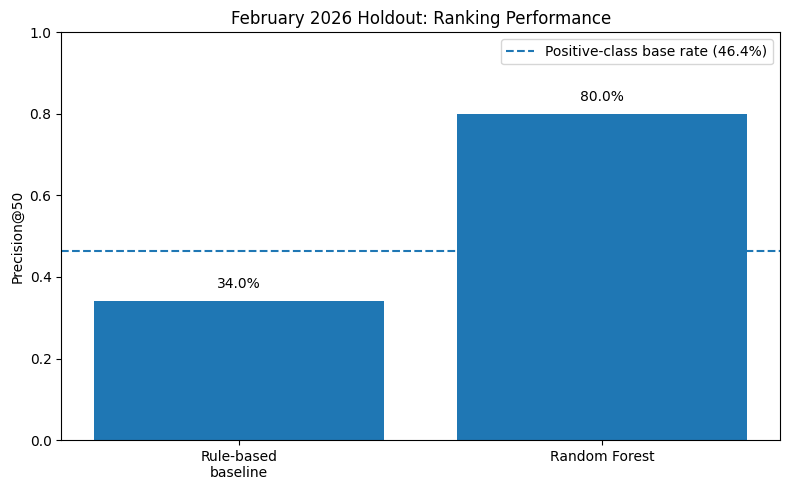

Saved: model_vs_baseline.png


In [1]:
import matplotlib.pyplot as plt

# Final audited evaluation values
baseline_precision_at_50 = 0.34
model_precision_at_50 = 0.80
base_rate = 0.464

methods = [
    "Rule-based\nbaseline",
    "Random Forest"
]

precision_values = [
    baseline_precision_at_50,
    model_precision_at_50
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(methods, precision_values)

# Positive-class base rate as reference
ax.axhline(
    base_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Positive-class base rate ({base_rate:.1%})"
)

ax.set_ylabel("Precision@50")
ax.set_title("February 2026 Holdout: Ranking Performance")
ax.set_ylim(0, 1)

for bar, value in zip(bars, precision_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

ax.legend()

fig.tight_layout()

figure_path = "model_vs_baseline.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved: {figure_path}")

### Time-aware validation design

The model was trained on October–December 2025, selected using January
2026, and evaluated once on the February 2026 holdout.

In [2]:
import pandas as pd
validation_timeline = pd.DataFrame({
    "Period": [
        "October–December 2025",
        "January 2026",
        "February 2026"
    ],
    "Role": [
        "Model training",
        "Model selection",
        "Final holdout evaluation"
    ]
})

display(validation_timeline)

,Period,Role
0,October–December 2025,Model training
1,January 2026,Model selection
2,February 2026,Final holdout evaluation


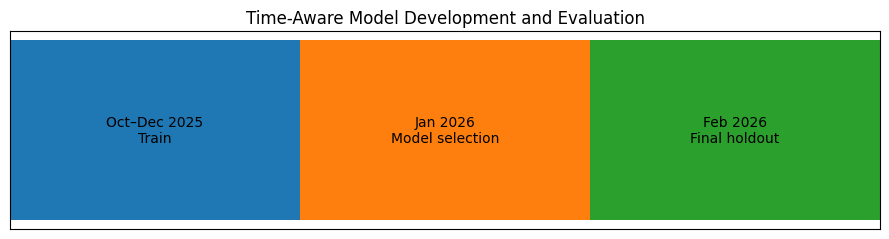

Figure saved to: validation_timeline.png


In [3]:
timeline = pd.DataFrame({
    "Period": [
        "Oct–Dec 2025",
        "Jan 2026",
        "Feb 2026"
    ],
    "Role": [
        "Train",
        "Model selection",
        "Final holdout"
    ]
})

fig, ax = plt.subplots(figsize=(9, 2.5))

for i, row in timeline.iterrows():
    ax.barh(
        0,
        1,
        left=i,
        height=0.5
    )

    ax.text(
        i + 0.5,
        0,
        f"{row['Period']}\n{row['Role']}",
        ha="center",
        va="center"
    )

ax.set_xlim(0, len(timeline))
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Time-Aware Model Development and Evaluation")

fig.tight_layout()

figure_1_path = "validation_timeline.png"

fig.savefig(
    figure_1_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_1_path}")

### Ranked recommendation preview

The action queue contains the 50 highest-scoring candidates.
The paper shows a small public-safe preview without client or content
identifiers.

In [4]:
!git clone https://github.com/innouguru/flyrank-internship-ml.git

fatal: destination path 'flyrank-internship-ml' already exists and is not an empty directory.


In [5]:
import pandas as pd
from pathlib import Path


# Define the location of the cloned repository in the Colab environment.
repo = Path("/content/flyrank-internship-ml")


# The validated outputs from Weeks 4, 6, and 7 are stored here.
output_dir = repo / "work" / "outputs"


# Load the Week-4 rule-based baseline output.
baseline = pd.read_csv(
    output_dir / "baseline_action_score.csv"
)


# Load the Week-6 top-50 model recommendations.
top50 = pd.read_csv(
    output_dir / "top_50_recommendation.csv"
)


# Load the Week-7 action queue built from the validated recommendations.
action_queue = pd.read_csv(
    output_dir / "week7_action_queue.csv"
)



In [6]:
# Select only the fields needed to show how the recommendation queue
# works. Client and content identifiers are deliberately excluded.
paper_action_queue = (
    action_queue[
        [
            "rank",
            "model_score",
            "reason_code",
            "recommended_action"
        ]
    ]
    .head(10)
    .copy()
)


# Round the model score for readability in the paper.
paper_action_queue["model_score"] = (
    paper_action_queue["model_score"].round(3)
)


# Display the first 10 ranked recommendations.
display(paper_action_queue)

,rank,model_score,reason_code,recommended_action
0,1,0.919,CTR_BELOW_POSITION_PEERS,SERP_REVIEW
1,2,0.903,CTR_BELOW_POSITION_PEERS,SERP_REVIEW
2,3,0.900,CTR_BELOW_POSITION_PEERS,SERP_REVIEW
3,4,0.891,CTR_BELOW_POSITION_PEERS,SERP_REVIEW
4,5,0.885,CTR_BELOW_POSITION_PEERS,SERP_REVIEW
5,6,0.885,CTR_BELOW_POSITION_PEERS,SERP_REVIEW
6,7,0.877,CTR_BELOW_POSITION_PEERS,MONITOR
7,8,0.876,CTR_BELOW_POSITION_PEERS,SERP_REVIEW
8,9,0.876,CTR_BELOW_POSITION_PEERS,SERP_REVIEW
9,10,0.872,CTR_BELOW_POSITION_PEERS,SERP_REVIEW


### Initial action distribution

The action playbook routes candidates according to their search exposure.
Pages with limited exposure are monitored, while pages with sufficient
exposure receive an initial SERP review recommendation.

In [7]:
# Count the number of candidates assigned to each initial action.
action_counts = (
    action_queue["recommended_action"]
    .value_counts()
    .rename_axis("Recommended action")
    .reset_index(name="Number of candidates")
)


# Display the action counts as a table.
display(action_counts)

,Recommended action,Number of candidates
0,SERP_REVIEW,41
1,MONITOR,9


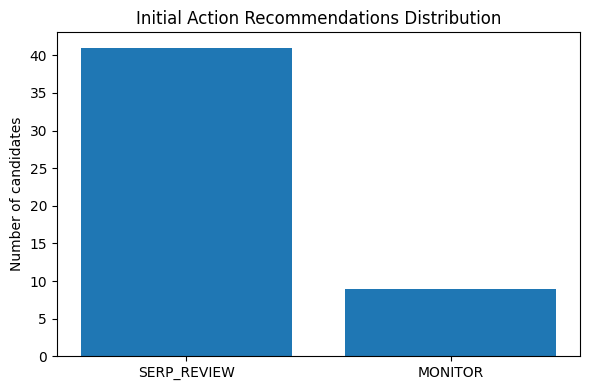

Figure saved to: initial_action_recommendations_distribution.png


In [8]:
# Visualize how the 50 ranked candidates were distributed
# across the initial actions defined in the Week-7 playbook.
plt.figure(figsize=(6, 4))

plt.bar(
    action_counts["Recommended action"],
    action_counts["Number of candidates"]
)

plt.ylabel("Number of candidates")
plt.title("Initial Action Recommendations Distribution")

plt.tight_layout()
plt.show()

# Save the existing initial action recommendation chart
# directly in the notebook's current working directory.
figure_3_path = "initial_action_recommendations_distribution.png"

fig.savefig(
    figure_3_path,
    dpi=200,
    bbox_inches="tight"
)

print(f"Figure saved to: {figure_3_path}")

## ML-12: Communication Outputs

This section summarizes the project for three different audiences:
a short technical demo, a public-facing social post, and a concise
employer-facing summary.

### 5-Minute Demo Outline

**0:00–0:40 — Problem and decision**

Editors have limited time and resources to review the large number of
content pages they manage. This project asks:

> Which content pages should be prioritized for review based on their
> search and engagement signals?

The system is designed to support the decision by producing a ranked
list of pages for human review.

**0:40–1:20 — Data and framing**

The analysis uses the FlyRank ML Internship dataset and focuses on
content performance from October 2025 through February 2026.

The original daily performance data was aggregated to monthly
client-content observations. Five current-month search and engagement
signals were used as model features.

The task was framed as a scoring and ranking problem.

**1:20–2:10 — Baseline and target**

The rule-based baseline first identified candidates whose CTR was at least
30% below the median CTR of their position peers.

The model then learned whether a candidate would reach or exceed the
following month's position-peer median CTR.

This made the target a future peer-relative CTR outcome rather than a
direct measure of whether a content refresh was successful.

**2:10–3:10 — Model and honest evaluation**

A Random Forest was trained using October–December 2025 data.

January 2026 was used for model selection, while February 2026 was kept
as the final holdout.

The primary metric was Precision@50 because the practical decision is
to prioritize a limited number of pages for editorial review.

The Random Forest achieved a measured Precision@50 of 0.80 on the
February holdout, compared with 0.34 for the Week-4 baseline.

**3:10–4:10 — From model score to action**

The model produces a score for each candidate and ranks the candidates
from highest to lowest priority.

The action playbook then converts the ranked output into an
initial review recommendation. Candidates with limited search exposure
are marked for monitoring, while candidates with sufficient exposure
receive an initial SERP review recommendation.

The output is a decision-support queue, not an automated editorial
verdict.

**4:10–5:00 — Limitations and takeaway**

The result shows that the Random Forest produced a stronger ranking than
the rule-based baseline under the February holdout evaluation.

However, the model does not establish causality and does not determine
whether a page should actually be refreshed. The target is a proxy for
future peer-relative CTR recovery, and the evaluation covers one
historical holdout period.

The main takeaway is that the project turns observable content
performance signals into a validated ranking that can help editors
focus their limited review capacity.

### Social-Post Cut

Editors often have limited time and resources to review the many content
pages they manage.

For my FlyRank ML Internship capstone, I built a machine learning ranking
system to help prioritize which content pages should be reviewed first.

I started with a position-aware CTR baseline, then trained a Random Forest
using search and engagement signals. I used a time-aware evaluation:
October–December 2025 for training, January 2026 for model selection, and
February 2026 as the final holdout.

On the February holdout, the Random Forest achieved a measured
Precision@50 of 0.80 compared with 0.34 for the rule-based baseline.

The model does not decide that a page should be refreshed, and the result
does not establish causality. Instead, it provides editors with a ranked
review queue that can help them focus their limited attention.

This project helped me understand that building an ML system is more than
training a model. The problem definition, target design, leakage checks,
temporal validation, evaluation metric, and how the output is used all
matter.

### 3-Sentence Employer-Facing Summary

I built an end-to-end machine learning ranking system that turns search
and engagement signals into a prioritized content-review queue, starting
from problem framing and a rule-based baseline through model development,
leakage auditing, time-aware validation, and an action playbook.

Using a Random Forest, I measured a Precision@50 of 0.80 on a February 2026
holdout compared with 0.34 for the rule-based baseline.

The project strengthened my ability to build and evaluate ML systems
honestly, communicate model limitations, and translate model outputs into
decision-support recommendations rather than treating predictions as
automatic decisions.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
